In [1]:
import os
import math
from typing import List, Optional, Dict, Tuple, Iterable, Union
from dataclasses import dataclass, field    
from DRDViz import DRDViz

In [2]:
import sys
try:
    sys.stdout.reconfigure(line_buffering=True)
except Exception:
    pass


In [3]:
# ------------------------------
# 1) Part 0 Search node
# ------------------------------
class SearchNode:
    def __init__(self, label, pathcost=0):
        self.label = label
        self.pathcost = pathcost
    @property
    def value(self):
        return self.pathcost
    def showBasic(self):
        print((self.label, self.value))
        return (self.label, self.value)

# ------------------------------
# 1b) Part 1 node 
# ------------------------------
@dataclass(order=True)
class _P1Node:
    # order keys for sorting OPEN
    sort_f: float = field(init=False, repr=False, compare=True)
    sort_g: float = field(init=False, repr=False, compare=False)
    sort_label: str = field(init=False, repr=False, compare=False)

    # payload
    label: str = field(compare=False)
    g: float = field(default=0.0, compare=False)
    h: float = field(default=0.0, compare=False)
    f: float = field(default=0.0, compare=False)
    depth: int = field(default=0, compare=False)
    parent: Optional["__class__"] = field(default=None, compare=False)

    def __post_init__(self):
        self.sort_f = self.f
        self.sort_g = self.g
        self.sort_label = self.label.upper()

    def open_repr(self, informed: bool) -> str:
        gfmt = f"{self.g:.0f}" if float(self.g).is_integer() else f"{self.g:.2f}"
        if not informed:
            # required format: <LABEL;DEPTH;g;h;f> (Part 1 prints 0 for h in uninformed)
            return f"{self.label.upper()};{self.depth};{gfmt}; {0.00:0.2f};{float(self.g):.2f}"
        return f"{self.label.upper()};{self.depth};{gfmt}; {self.h:.2f};{self.f:.2f}"

# ------------------------------
# 2) Modified Part 0 searcher so as to be compatible and work with my Part 1)
# ------------------------------
class Searcher:
    def __init__(self, filename: str, searchType: str = "DEPTH", verbose: bool = True):
        # --- viz / map ---
        self.myViz = DRDViz()
        self.filename = self._resolve_filename(filename)
        self.myViz.loadGraphFromFile(self.filename)
        self.myViz.plot()  # keep the visual like last time

        # --- Part 0 state---
        self.open: List[SearchNode] = []
        self.start: Optional[str] = None
        self.goal: Optional[Union[str, List[str]]] = None

        # --- Part 1 settings/state (new) ---
        self.searchType = str(searchType).upper() if searchType is not None else "DEPTH"
        assert self.searchType in ("DEPTH", "BREADTH", "BEST", "A*"), \
            "searchType must be one of DEPTH, BREADTH, BEST, A*"
        self.verbose = bool(verbose)
        self._p1_goals: List[str] = []
        self._p1_open: List[_P1Node] = []     
        self._p1_closed: set[str] = set()

  
    def _resolve_filename(self, filename: str) -> str:
        if os.path.exists(filename):
            return filename
        base = filename.lower()
        dirname = os.path.dirname(filename) or os.getcwd()
        for cand in os.listdir(dirname):
            if cand.lower() == base:
                return os.path.join(dirname, cand)
        # allow stem containment & case-insensitivity (helps with 30Node.txt.txt, 10test.txt, 50test.txt)
        stem = os.path.splitext(os.path.basename(filename))[0].lower()
        for cand in os.listdir(dirname):
            if stem in cand.lower():
                return os.path.join(dirname, cand)
        return filename

    def setStartGoal(self, start: str, goal: Union[str, List[str]]) -> None:
        """For Part 0 (single goal string) AND Part 1 (string or list)."""
        self.start = start.upper()
        # goal may be string or list for Part 1; we keep self.goal as given for backward compatibility
        self.goal = goal
        # viz
        self.myViz.markStart(self.start)
        if isinstance(goal, (list, tuple, set)):
            for g in goal:
                self.myViz.markGoal(str(g).upper())
        else:
            self.myViz.markGoal(str(goal).upper())
        # Part 0 OPEN:
        self.open = [SearchNode(self.start, 0)]
        # Part 1 seeds:
        self._p1_goals = [str(g).upper() for g in (goal if isinstance(goal, (list, tuple, set)) else [goal])]
        h0 = self._p1_h(self.start)
        self._p1_open = [_P1Node(label=self.start, g=0.0, h=h0, f=self._p1_eval(0.0, h0), depth=0)]
        self._p1_closed = set()

    def reset(self) -> None:
        """Part 0 reset"""
        if self.start is None or self.goal is None:
            return
        self.myViz.markStart(self.start)
        if isinstance(self.goal, (list, tuple, set)):
            for g in self.goal:
                self.myViz.markGoal(str(g).upper())
        else:
            self.myViz.markGoal(str(self.goal).upper())
        self.open = [SearchNode(self.start, 0)]
        # reset Part 1 lists
        h0 = self._p1_h(self.start)
        self._p1_open = [_P1Node(label=self.start, g=0.0, h=h0, f=self._p1_eval(0.0, h0), depth=0)]
        self._p1_closed = set()

    def _neighbors(self, label: str):
        """Return neighbors (child_label, edge_cost) using DRDViz edges."""
        neigh = []
        lab = label.upper()
        for e in self.myViz.edges:
            if e.endlabel1.upper() == lab:
                neigh.append((e.endlabel2.upper(), int(e.label)))
            elif e.endlabel2.upper() == lab:
                neigh.append((e.endlabel1.upper(), int(e.label)))
        return neigh

    # def successors(self, node: SearchNode):
    #     """Part 0 successors: alpha-sorted children with cumulative path costs from START."""
    #     kids = []
    #     for (child_label, edge_cost) in self._neighbors(node.label):
    #         kids.append(SearchNode(child_label, node.pathcost + edge_cost))
    #     kids.sort(key=lambda n: n.label)  # alphabetical
    #     return kids

    def insert_front(self, new_nodes):
        new_nodes = list(new_nodes)
        ignored = self._dedupe_merge(new_nodes, where='front')
        return ignored

    def insert_end(self, new_nodes):
        new_nodes = list(new_nodes)
        ignored = self._dedupe_merge(new_nodes, where='end')
        return ignored

    def insert_ordered(self, new_nodes):
        new_nodes = list(new_nodes)
        ignored = self._dedupe_merge(new_nodes, where='end')
        self.open.sort(key=lambda n: n.value)
        return ignored

    # def _dedupe_merge(self, new_nodes, where: str = 'end'):
    #     ignored: List[str] = []
    #     best: Dict[str, int] = {}
    #     for n in self.open:
    #         best[n.label] = min(best.get(n.label, n.value), n.value)
    #     merged: List[SearchNode] = []
    #     for n in new_nodes:
    #         prev = best.get(n.label)
    #         if prev is None or n.value < prev:
    #             best[n.label] = n.value
    #             merged.append(n)
    #         else:
    #             ignored.append(n.label)
    #     if where == 'front':
    #         self.open = merged + self.open
    #     else:
    #         self.open.extend(merged)
    #     return ignored

    # ---------- Part 1: heuristic and evaluation ----------
    def _p1_h(self, label: str) -> float:
        """Straight-line distance to nearest goal using DRDViz coordinates."""
        node = self.myViz.getNodeByLabel(label.upper())
        if node == 0 or node is None:
            return 0.0
        best = float('inf')
        for g in self._p1_goals:
            goal = self.myViz.getNodeByLabel(g)
            if goal == 0 or goal is None:
                continue
            d = math.dist([node.x, node.y], [goal.x, goal.y])
            if d < best:
                best = d
        return 0.0 if best == float('inf') else round(best, 2)

    def _p1_eval(self, g: float, h: float) -> float:
        if self.searchType == "A*":
            return round(g + h, 2)
        if self.searchType == "BEST":
            return round(h, 2)
        return round(g, 2)  # DEPTH / BREADTH

    def _p1_successors(self, parent: _P1Node) -> List[_P1Node]:
        kids: List[_P1Node] = []
        for (lab, c) in self._neighbors(parent.label):
            g2 = parent.g + float(c)
            h2 = self._p1_h(lab) if self.searchType in ("BEST", "A*") else 0.0
            f2 = self._p1_eval(g2, h2)
            kids.append(_P1Node(label=lab, g=g2, h=h2, f=f2, depth=parent.depth + 1, parent=parent))
        return kids

    # ---------- Part 1: insertion with duplicate policy ----------
    def _p1_insert(self, new_nodes: List[_P1Node]):
        def better(ex: _P1Node, cand: _P1Node) -> bool:
            if self.searchType == "BEST":
                return (cand.h < ex.h) or (cand.h == ex.h and cand.label.upper() < ex.label.upper())
            if self.searchType == "A*":
                return (cand.f < ex.f) or (cand.f == ex.f and (cand.g < ex.g or (cand.g == ex.g and cand.label.upper() < ex.label.upper())))
            return False  

        # dropping CLOSED
        new_nodes = [n for n in new_nodes if n.label.upper() not in self._p1_closed]

        # merge against OPEN
        idx = {n.label.upper(): i for i, n in enumerate(self._p1_open)}
        for n in new_nodes:
            k = n.label.upper()
            if k in idx:
                i = idx[k]
                if better(self._p1_open[i], n):
                    self._p1_open[i] = n
            else:
                # if self.searchType == "DEPTH":
                #     self._p1_open.insert(0, n)  # LIFO
                #     idx = {node.label.upper(): i for i, node in enumerate(self._p1_open)}
                # elif self.searchType == "BREADTH":
                #     self._p1_open.append(n)     # FIFO
                #     idx[k] = len(self._p1_open) - 1
                # elif self.searchType == "BEST":
                #     self._p1_open.append(n)
                #     self._p1_open.sort(key=lambda x: (x.h, x.label.upper()))
                #     idx = {node.label.upper(): i for i, node in enumerate(self._p1_open)}
                # else:  # A*
                #     self._p1_open.append(n)
                #     self._p1_open.sort(key=lambda x: (x.f, x.g, x.label.upper()))
                #     idx = {node.label.upper(): i for i, node in enumerate(self._p1_open)}

                
                if self.searchType == "DEPTH":
                    self._p1_open = new_nodes + self._p1_open
                elif self.searchType == "BREADTH":
                    self._p1_open.extend(new_nodes)
                elif self.searchType == "BEST":
                    self._p1_open.extend(new_nodes)
                    self._p1_open.sort(key=lambda x: (x.h, x.label.upper()))
                else:  # A*
                    self._p1_open.extend(new_nodes)
                    self._p1_open.sort(key=lambda x: (x.f, x.g, x.label.upper()))

    # ---------- Part 1: search ----------
    def search(self):
        """Run Part 1 search using self.searchType. Does not affect Part 0 OPEN."""
        informed = (self.searchType in ("BEST", "A*"))
        while self._p1_open:
            cur = self._p1_open.pop(0)
            if self.verbose:
                print(f"Exploring node: {cur.label.upper()}")
            if cur.label.upper() in set(self._p1_goals):
                path = self._p1_path(cur)
                print(f"Success! Reached goal node {cur.label.upper()} with path: {path}")
                return {"path": path, "cost": cur.g, "expanded": len(self._p1_closed) }
                print('\n')
           
            self._p1_closed.add(cur.label.upper())
            kids = self._p1_successors(cur)

            # if self.searchType == "DEPTH":
            #     # reverse so pushing to front preserves left-to-right alpha (A on top of stack)
            #     kids.sort(key=lambda n: n.label.upper(), reverse=True)

            if self.searchType in ("DEPTH", "BREADTH"):
                kids.sort(key=lambda n: n.label.upper())              
            elif self.searchType == "BEST":
                kids.sort(key=lambda n: (n.h, n.label.upper()))       
            else:  # A*
                kids.sort(key=lambda n: (n.f, n.g, n.label.upper())) 

            if self.verbose:
                print(f"inserting new children: {[k.label.upper() for k in kids]}")
            self._p1_insert(kids)
            if self.verbose:
                print("Open list: [" + ", ".join([f"'{n.open_repr(informed)}'" for n in self._p1_open]) + "]")
        print("Failed: no path found.")
        return None

    def _p1_path(self, node: _P1Node) -> List[str]:
        out = []
        cur = node
        while cur:
            out.append(cur.label.upper())
            cur = cur.parent
        return list(reversed(out))

# ------------------------------
# 3) Part 0 heuristic
# ------------------------------
def hSLD(label: str, searcher: Searcher):
    if searcher.goal is None:
        raise ValueError("Goal not set. Call setStartGoal first.")
    node = searcher.myViz.getNodeByLabel(label)
    # allow list of goals; pick nearest (so Part 0 can also visualize multi-goal)
    goals = [searcher.myViz.getNodeByLabel(str(g).upper()) for g in (searcher.goal if isinstance(searcher.goal, (list, tuple, set)) else [searcher.goal])]
    goals = [g for g in goals if g not in (0, None)]
    if node in (0, None) or not goals:
        raise ValueError(f"Unknown node label in hSLD: {label} or {searcher.goal}")
    best = min(math.dist([node.x, node.y], [g.x, g.y]) for g in goals)
    return round(best, 2)


In [4]:
# print('-'*20,'(Starting 10test.txt Searchtype: DEPTH)', '-'*20 )

C:\Users\adeba\OneDrive - Northern Arizona University\Documents\2nd Semester - Fall\CS 570 - Advanced Intellegent systems\Assignment4\Untitled Folder\DRDViz.py:96: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  plt.plot([x.x for x in self.nodes], [x.y for x in self.nodes], 'ko',
C:\Users\adeba\OneDrive - Northern Arizona University\Documents\2nd Semester - Fall\CS 570 - Advanced Intellegent systems\Assignment4\Untitled Folder\DRDViz.py:102: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot([edge.x1, edge.x2], [edge.y1, edge.y2], 'b-', color='k', linewidth=0.5)  # make the lines


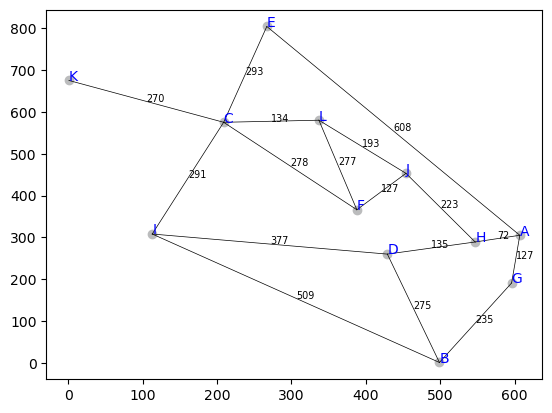

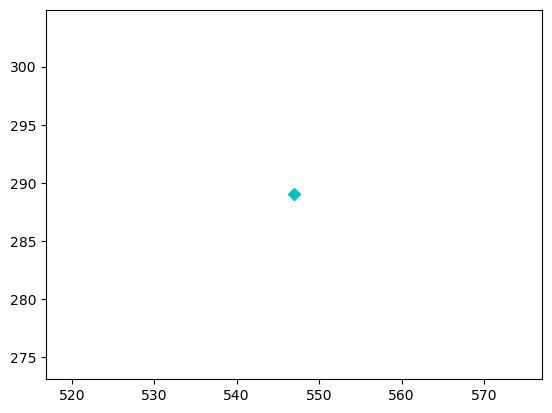

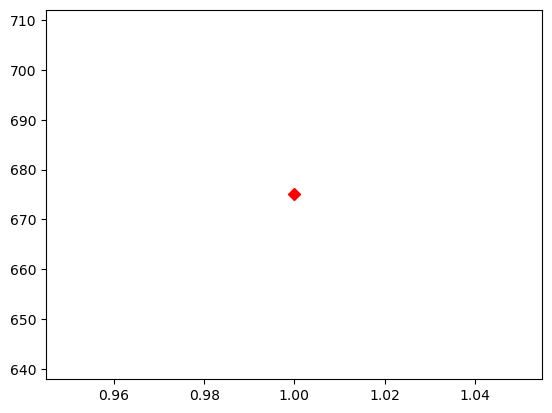

Exploring node: H
inserting new children: ['A', 'D', 'J']
Open list: ['A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00']
Exploring node: A
inserting new children: ['E', 'G', 'H']
Open list: ['E;2;680; 0.00;680.00', 'G;2;199; 0.00;199.00', 'E;2;680; 0.00;680.00', 'G;2;199; 0.00;199.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00']
Exploring node: E
inserting new children: ['A', 'C']
Open list: ['C;3;973; 0.00;973.00', 'G;2;199; 0.00;199.00', 'E;2;680; 0.00;680.00', 'G;2;199; 0.00;199.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00']
Exploring node: C

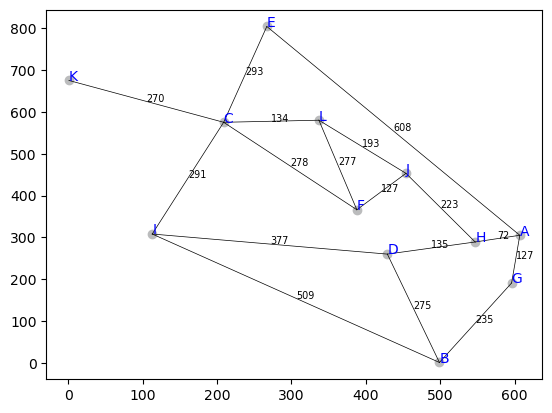

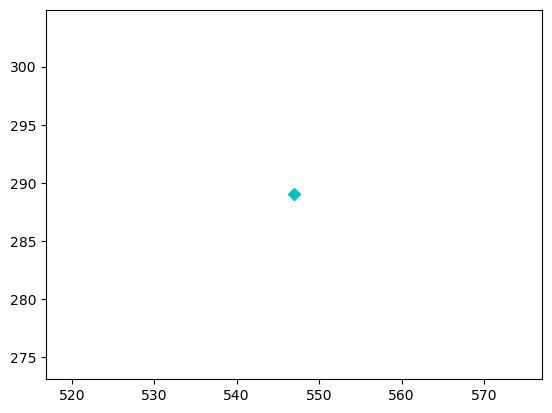

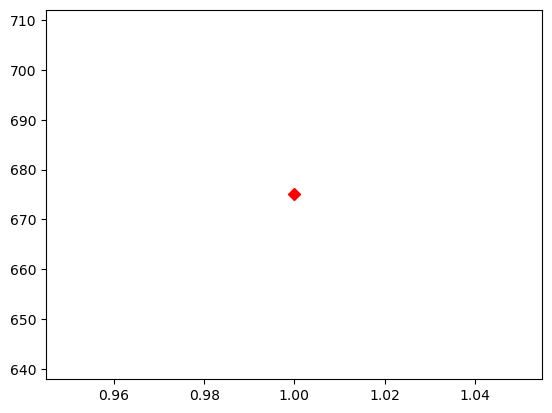

Exploring node: H
inserting new children: ['A', 'D', 'J']
Open list: ['A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00']
Exploring node: A
inserting new children: ['E', 'G', 'H']
Open list: ['D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'E;2;680; 0.00;680.00', 'G;2;199; 0.00;199.00', 'E;2;680; 0.00;680.00', 'G;2;199; 0.00;199.00']
Exploring node: D
inserting new children: ['B', 'H', 'I']
Open list: ['J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'A;1;72; 0.00;72.00', 'D;1;135; 0.00;135.00', 'J;1;223; 0.00;223.00', 'E;2;680; 0.00;680.00', 'G;2;199; 0.00;199.00', 'E;2;680; 0.00;680.00', 'G;2;199; 0.00;199.00', 'B;2;410; 0.00;410.00', 'I;2;512; 0.

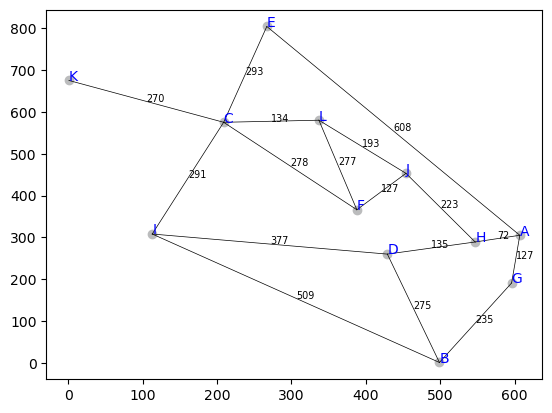

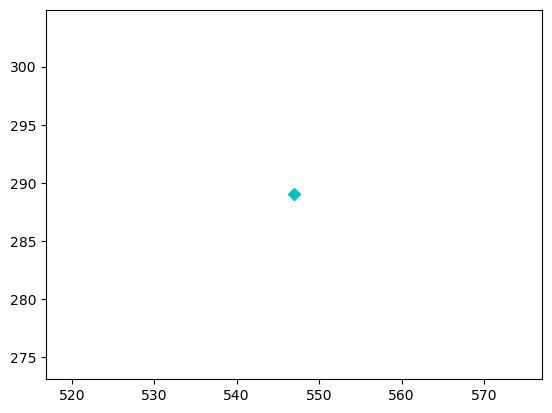

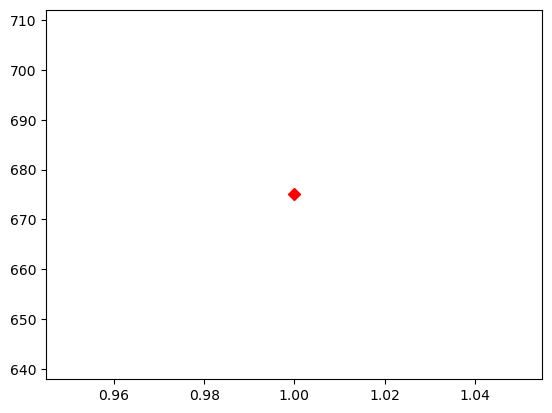

Exploring node: H
inserting new children: ['J', 'D', 'A']
Open list: ['J;1;223; 504.47;504.47', 'J;1;223; 504.47;504.47', 'J;1;223; 504.47;504.47', 'D;1;135; 596.16;596.16', 'D;1;135; 596.16;596.16', 'D;1;135; 596.16;596.16', 'A;1;72; 710.03;710.03', 'A;1;72; 710.03;710.03', 'A;1;72; 710.03;710.03']
Exploring node: J
inserting new children: ['L', 'F', 'H']
Open list: ['L;2;416; 349.17;349.17', 'L;2;416; 349.17;349.17', 'F;2;350; 495.23;495.23', 'F;2;350; 495.23;495.23', 'J;1;223; 504.47;504.47', 'J;1;223; 504.47;504.47', 'D;1;135; 596.16;596.16', 'D;1;135; 596.16;596.16', 'D;1;135; 596.16;596.16', 'A;1;72; 710.03;710.03', 'A;1;72; 710.03;710.03', 'A;1;72; 710.03;710.03']
Exploring node: L
inserting new children: ['C', 'F', 'J']
Open list: ['C;3;550; 230.79;230.79', 'L;2;416; 349.17;349.17', 'F;2;350; 495.23;495.23', 'F;2;350; 495.23;495.23', 'F;3;693; 495.23;495.23', 'J;1;223; 504.47;504.47', 'J;1;223; 504.47;504.47', 'D;1;135; 596.16;596.16', 'D;1;135; 596.16;596.16', 'D;1;135; 596.16

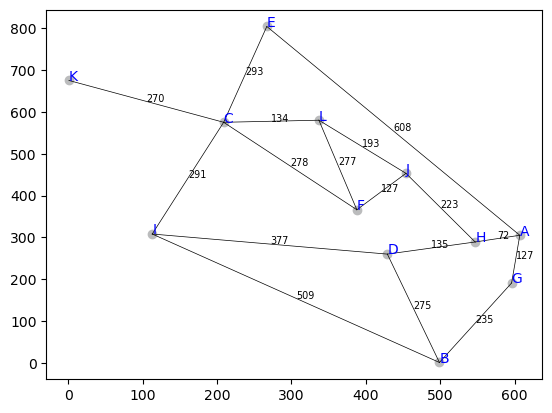

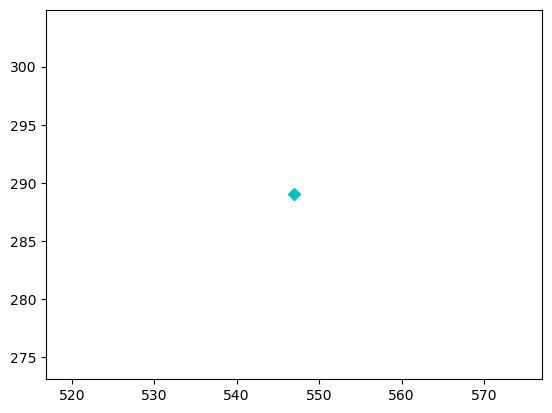

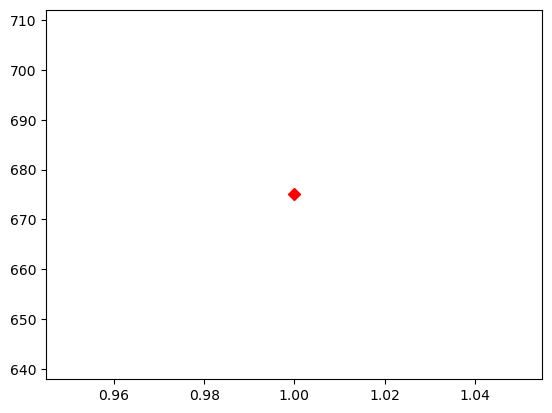

Exploring node: H
inserting new children: ['J', 'D', 'A']
Open list: ['J;1;223; 504.47;727.47', 'J;1;223; 504.47;727.47', 'J;1;223; 504.47;727.47', 'D;1;135; 596.16;731.16', 'D;1;135; 596.16;731.16', 'D;1;135; 596.16;731.16', 'A;1;72; 710.03;782.03', 'A;1;72; 710.03;782.03', 'A;1;72; 710.03;782.03']
Exploring node: J
inserting new children: ['L', 'F', 'H']
Open list: ['J;1;223; 504.47;727.47', 'J;1;223; 504.47;727.47', 'D;1;135; 596.16;731.16', 'D;1;135; 596.16;731.16', 'D;1;135; 596.16;731.16', 'L;2;416; 349.17;765.17', 'L;2;416; 349.17;765.17', 'A;1;72; 710.03;782.03', 'A;1;72; 710.03;782.03', 'A;1;72; 710.03;782.03', 'F;2;350; 495.23;845.23', 'F;2;350; 495.23;845.23']
Exploring node: J
inserting new children: ['L', 'F', 'H']
Open list: ['J;1;223; 504.47;727.47', 'D;1;135; 596.16;731.16', 'D;1;135; 596.16;731.16', 'D;1;135; 596.16;731.16', 'L;2;416; 349.17;765.17', 'L;2;416; 349.17;765.17', 'A;1;72; 710.03;782.03', 'A;1;72; 710.03;782.03', 'A;1;72; 710.03;782.03', 'F;2;350; 495.23;84

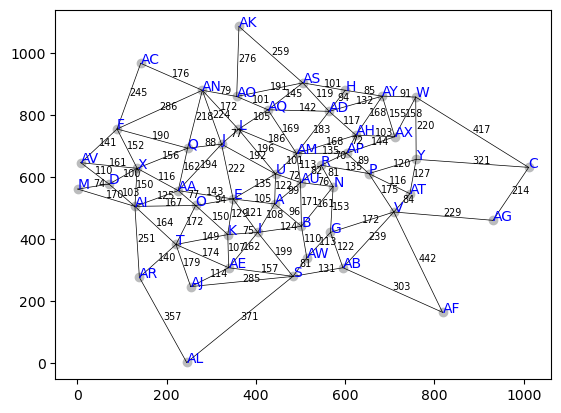

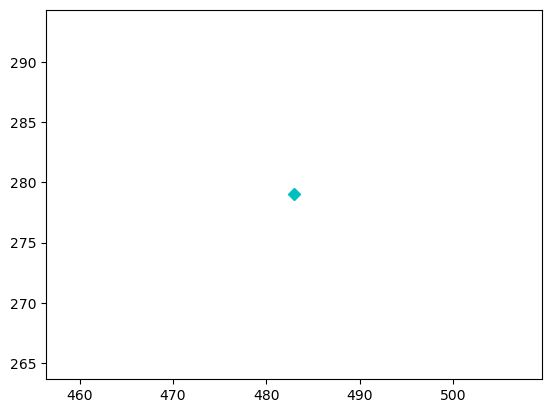

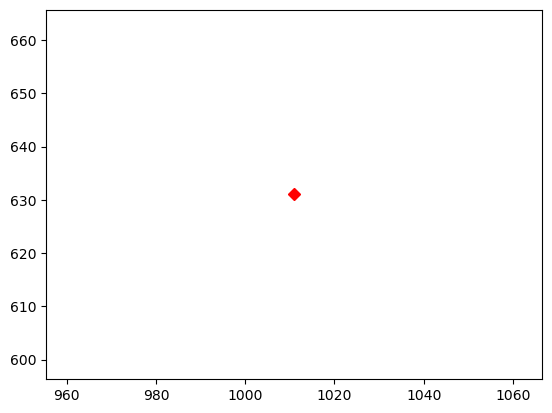

Success! Reached goal node C with path: ['S', 'AB', 'G', 'AW', 'B', 'A', 'AU', 'AM', 'AD', 'AH', 'AP', 'AX', 'W', 'C']


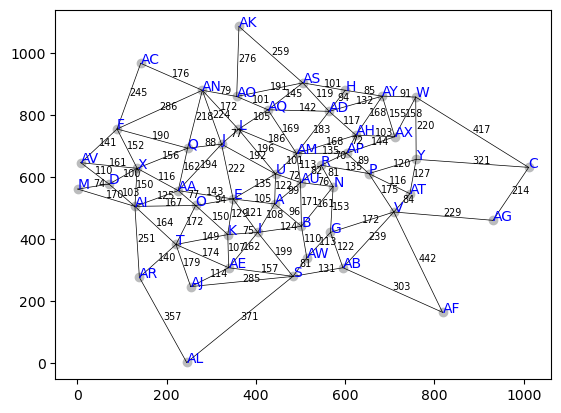

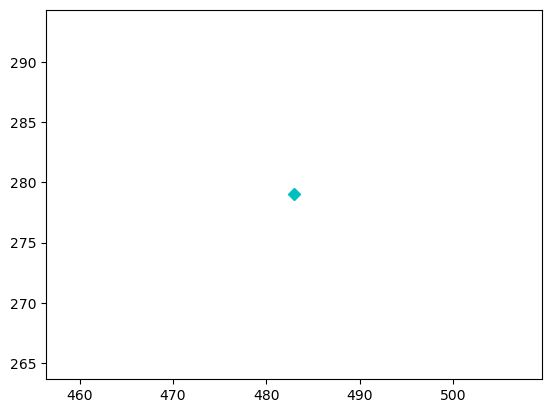

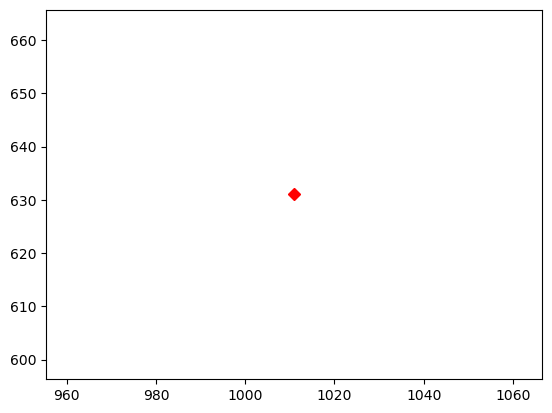

Success! Reached goal node C with path: ['S', 'AB', 'V', 'AG', 'C']


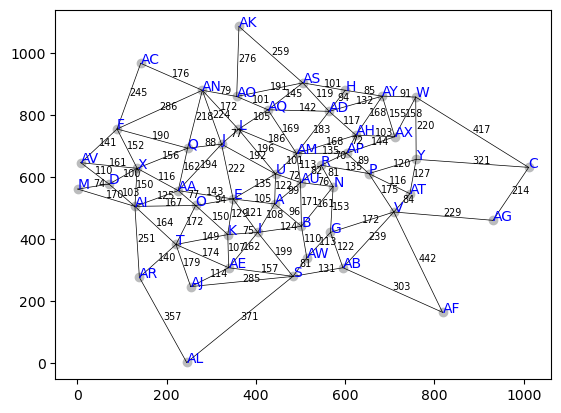

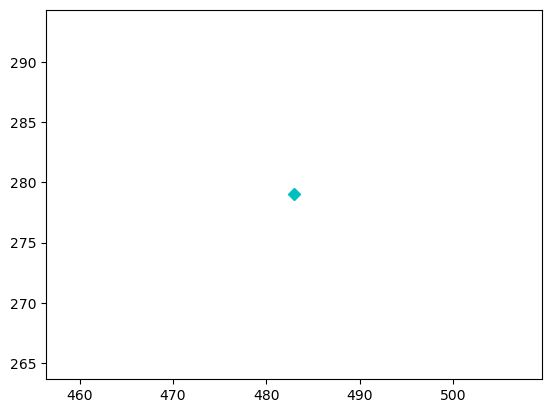

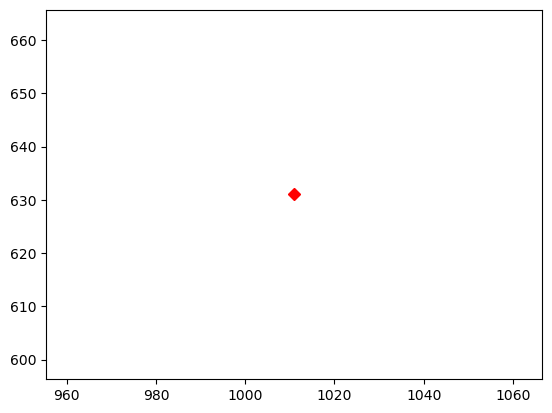

Success! Reached goal node C with path: ['S', 'AB', 'V', 'AG', 'C']


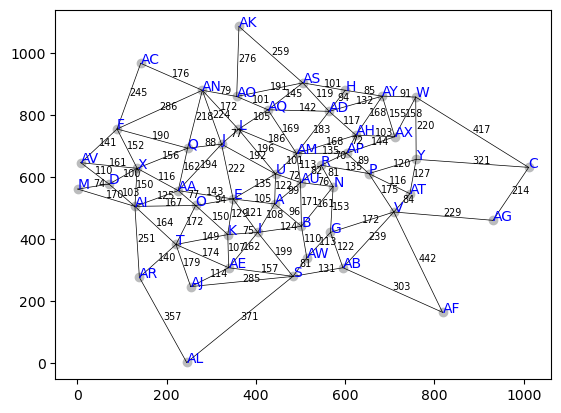

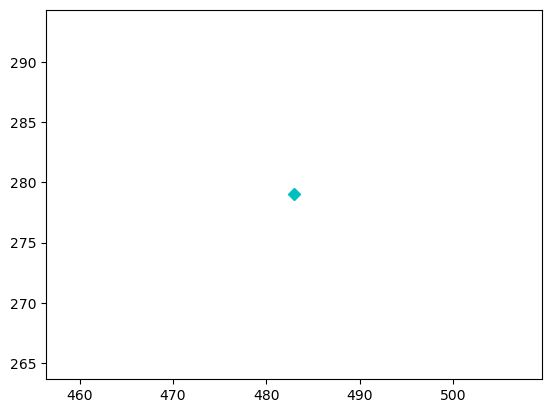

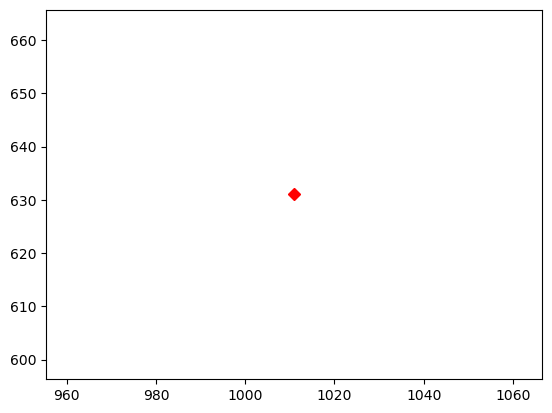

Success! Reached goal node C with path: ['S', 'AW', 'G', 'V', 'AG', 'C']


{'path': ['S', 'AW', 'G', 'V', 'AG', 'C'], 'cost': 809.0, 'expanded': 9}

In [5]:
# Define Searcher class here.

# 10test.txt map
x=Searcher("10test.txt", searchType="DEPTH", verbose=True)
x.setStartGoal('h','k')
x.search()

x=Searcher("10test.txt", searchType="BREADTH", verbose=True)
x.setStartGoal('h','k')
x.search()

x=Searcher("10test.txt", searchType="BEST", verbose=True)
x.setStartGoal('h','k')
x.search()

x=Searcher("10test.txt", searchType="A*", verbose=True)
x.setStartGoal('h','k')
x.search()

# 50test.txt map
x=Searcher("50test.txt", searchType="DEPTH", verbose=False)
x.setStartGoal('s','c')
x.search()

x=Searcher("50test.txt", searchType="BREADTH", verbose=False)
x.setStartGoal('s','c')
x.search()

x=Searcher("50test.txt", searchType="BEST", verbose=False)
x.setStartGoal('s','c')
x.search()

x=Searcher("50test.txt", searchType="A*", verbose=False)
x.setStartGoal('s','c')
x.search()

